##  **RNN / LSTM for Sequences**

###  What is Sequential Data?
Sequential data has **order** — each element depends on previous ones.

Examples:
- Text (words in a sentence)
- Time-series (stock prices, weather)
- Speech signals
- Sensor readings



## Recurrent Neural Network (RNN)

An RNN processes data **one step at a time**, remembering past information.

- Takes current input
- Combines it with previous memory (hidden state)
- Passes memory forward

*Think:*  
> “What I see now + what I remember so far”

---

### ❌ Limitation of RNN
- Struggles with **long sequences**
- Suffers from **vanishing gradients**
- Forgets earlier information

---

##  Long Short-Term Memory (LSTM)

### 🚀 Why LSTM?
LSTM is a special type of RNN designed to **remember important information for a long time**.

---

###  Key Components of LSTM
- **Forget Gate** → what to forget  
- **Input Gate** → what to remember  
- **Output Gate** → what to output  

 *Think:*  
> “Keep what matters, forget what doesn’t”

---

##  RNN vs LSTM (Quick Comparison)

| Feature | RNN | LSTM |
|------|-----|------|
| Handles long sequences | ❌ Poor | ✅ Excellent |
| Memory control | ❌ Weak | ✅ Strong (gates) |
| Vanishing gradient | ❌ Yes | ✅ Reduced |
| Real-world usage | Rare | Very common |



##  Where RNN / LSTM Are Used
- Sentiment analysis
- Language translation
- Stock price prediction
- Speech recognition
- Chatbots



##  Key Takeaway
- **RNN** → good for short sequences  
- **LSTM** → best for long-term dependencies  
- Sequence learning needs **memory**, and LSTM provides it 🧠


## 🗣️ Real-World Example: Sentiment Analysis using LSTM  
*(Positive / Negative Review Classification)*



##  Problem Statement

👉 Given a **sentence (sequence of words)**, predict the sentiment:

- **Positive sentiment → 1**
- **Negative sentiment → 0**



### 📌 Examples

| Sentence                    | Sentiment |
|-----------------------------|-----------|
| "The movie was amazing"     | 😊 Positive |
| "The service was terrible"  | 😡 Negative |



##  Why Use LSTM for Sentiment Analysis?

- Text data is a **sequence of words**
- **Word order matters** for meaning

❌ *“not good”*  
✅ *“good not bad”*

Even though the same words appear, the **sentiment changes based on order**.

---

### Key Advantage of LSTM
- LSTM **remembers context across words**
- Captures long-term dependencies in sentences
- Helps understand negation, emphasis, and flow of meaning

 *LSTM reads the sentence like a human — word by word, remembering what came before.*


### 📦 Step 1: Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

### 📝 Step 2: Small Real-World Dataset

In [3]:
sentences = [
    "i love this movie",
    "this film was amazing",
    "i hate this movie",
    "this film was terrible"
]

labels = torch.tensor([1, 1, 0, 0])  # 1=Positive, 0=Negative

### 🔡 Step 3: Tokenization & Encoding

In [4]:
# Build vocabulary
vocab = {}
idx = 1  # start from 1 (0 = padding)

for sentence in sentences:
    for word in sentence.split():
        if word not in vocab:
            vocab[word] = idx
            idx += 1

vocab_size = len(vocab) + 1

### Step 4: Convert Sentences to Sequences

In [5]:
max_len = 5

def encode(sentence):
    tokens = [vocab[word] for word in sentence.split()]
    tokens += [0] * (max_len - len(tokens))  # padding
    return tokens

X = torch.tensor([encode(s) for s in sentences])
y = labels.float()

### Step 5: LSTM Sentiment Model

In [6]:
class SentimentLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 10)
        self.lstm = nn.LSTM(10, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return self.sigmoid(out)

### ⚙️ Step 6: Training

In [7]:
model = SentimentLSTM()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    output = model(X).squeeze()
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 50, Loss: 0.0003
Epoch 100, Loss: 0.0002
Epoch 150, Loss: 0.0001
Epoch 200, Loss: 0.0001


### ✅ Step 7: Test with a New Sentence

In [8]:
test_sentence = "i love this film"
test_input = torch.tensor([encode(test_sentence)])

prediction = model(test_input)
print("Sentiment Score:", prediction.item())

Sentiment Score: 0.9998959302902222


In [9]:
test_sentence = "amazing movie"
test_input = torch.tensor([encode(test_sentence)])

prediction = model(test_input)
print("Sentiment Score:", prediction.item())

Sentiment Score: 0.9998970031738281


## 📈 Stock Price Prediction using LSTM (Time Series)


## 🎯 Problem Statement

👉 Given **past stock prices**, predict the **next day’s price**.

### Example
Day:    1    2    3    4    5  
Price: 100  102  101  103  104  

Predict → **Day 6 price**


---

##  Why Use LSTM for Stock Data?

- Stock prices are **time-dependent**
- Past prices influence future prices
- Patterns unfold over time (trends, momentum)

###  Why LSTM Works Well
- LSTM can **remember trends and patterns**
- Handles long-term dependencies in time series
- More effective than traditional RNNs for financial data

 *LSTM learns from history to forecast the future.*


## Step 1: Import Required Libraries

### Why this step matters

We combine:

- **Numerical computing** (NumPy, Pandas)  
- **Live financial data** (Yahoo Finance)  
- **Visualization** (Matplotlib)  
- **Scaling** (LSTM needs normalized data)  
- **Deep learning** (TensorFlow / Keras)
**bold text**

In [10]:
pip install yfinance pandas numpy matplotlib scikit-learn tensorflow

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

## Step 2: Fetch Live Stock Price Data


- Download historical Apple (AAPL) stock prices  
- Use only the closing price, which is most commonly modeled in finance

In [12]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
prices = data['Close'].values.reshape(-1, 1)

/tmp/ipython-input-947942598.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [13]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468254,72.528574,71.223252,71.476592,135480400
2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153503,73.455103,71.698589,71.698589,132079200


**Visualize the Data**

Total data points: 1006


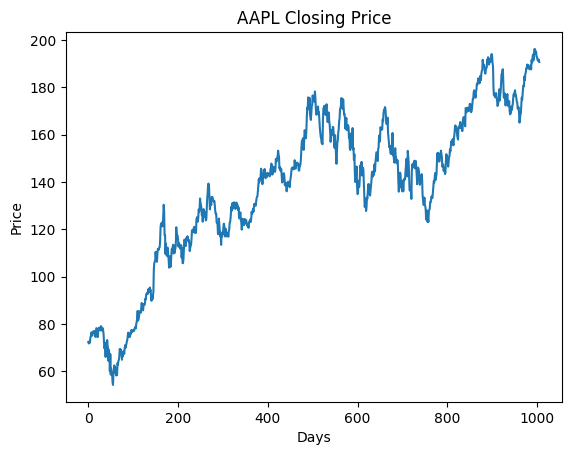

In [14]:
print("Total data points:", len(prices))
plt.plot(prices)
plt.title("AAPL Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

## Step 3: Data Preprocessing: Scaling


- LSTMs are very sensitive to magnitude.  
- $150 vs $1 looks huge to the model  
- We normalize everything to **[0, 1]**

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

## Step 4: Create Time Series Sequences

- “Use the last 60 days of prices to predict tomorrow’s price.”

In [16]:
X, y = [], []
window_size = 60

for i in range(window_size, len(scaled_prices)):
    X.append(scaled_prices[i-window_size:i, 0])
    y.append(scaled_prices[i, 0])

## Step 5: Reshape Data for LSTM Input

### Why reshape?
- LSTM expects **3D input**:  
  **(samples, time_steps, features)**

In [17]:
X, y = np.array(X), np.array(y)
# Reshape for LSTM: [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

## Step 6: Build the LSTM Model


- Two stacked LSTM layers → better temporal understanding  
- Dropout → reduces overfitting  
- Dense layer → final numeric prediction  

In [18]:
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2), # Prevents overfitting
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1) # Final price prediction
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Step 7: Compile and Train the Model

### Training configuration
- Adam optimizer → fast convergence  
- MSE loss → standard for regression  
- Epochs = 10 → fast demo training  

In [19]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - loss: 0.1056
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0107
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0062
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0058
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0057
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0050
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0048
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0043
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0046
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0048


## Step 8: Predict Tomorrow’s Stock Price (Live Demo Moment)

### Steps
- Take last 60 days  
- Predict next value  
- Convert back to real price  


In [20]:
last_60_days = scaled_prices[-60:].reshape(1, 60, 1)
prediction_scaled = model.predict(last_60_days)
prediction = scaler.inverse_transform(prediction_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


## Step 9: Final Output

In [21]:
print(f"Predicted Price for tomorrow: ${prediction[0][0]:.2f}")

Predicted Price for tomorrow: $191.14


## Step 10: Model Evaluation & Visualization (Train–Test Analysis)

### 1️⃣ Split Data into Training and Test Sets

#### Why we split the data
- We train on past data  
- We test on unseen future data  
- This simulates real-world forecasting

In [22]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

### 2️⃣ Train the Model on Historical Data

#### What happens here
- Model learns temporal patterns from 80% of the data  
- More epochs = deeper pattern learning

In [23]:
model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

### 3️⃣ Predict Prices on the Test Set

#### Why predict on test data
This checks whether the model:
- Learned general patterns  
- Not just memorized training data  

In [24]:
predicted_prices_scaled = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


### 4️⃣ Retrieve Actual Stock Prices

#### Purpose
- We need actual prices to compare against predictions

In [25]:
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

### 5️⃣ Visualize Predictions vs Actual Prices

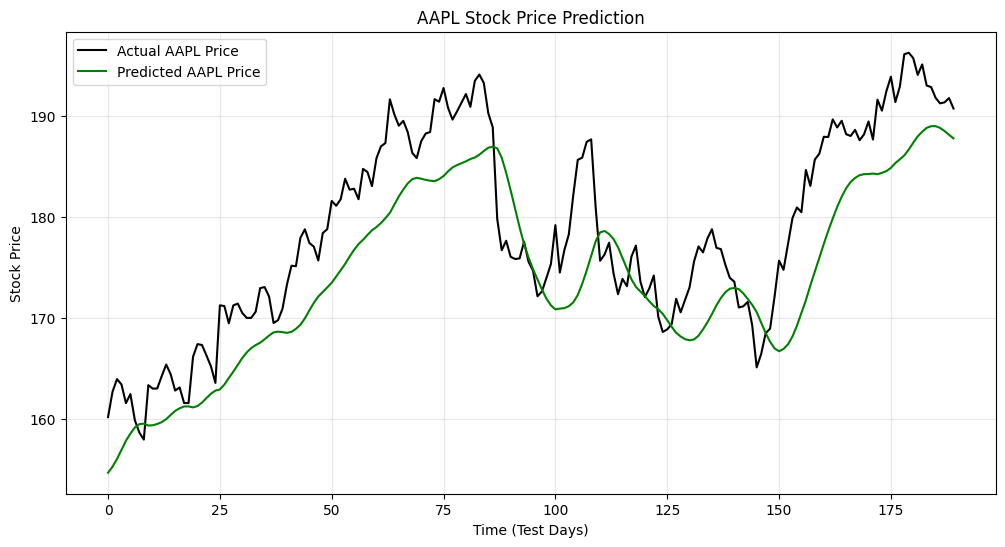

In [26]:
plt.figure(figsize=(12,6))
plt.plot(actual_prices, color='black', label=f'Actual {ticker} Price')
plt.plot(predicted_prices, color='green', label=f'Predicted {ticker} Price')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time (Test Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 📐 Model Performance Evaluation (RMSE)

In [27]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f"Model Accuracy: On average, the model is off by ${rmse:.2f}")

Model Accuracy: On average, the model is off by $6.09
